In [1]:
import urllib.request
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
urllib.request.urlretrieve._opener = None

import csv
from datetime import datetime
import json
from pathlib import Path
import pickle

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
# from pytorch_metric_learning.distances import LpDistance
# from pytorch_metric_learning.losses import TripletMarginLoss
# from pytorch_metric_learning.miners import TripletMarginMiner
# from pytorch_metric_learning.samplers import MPerClassSampler
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import models
import torchvision.transforms as T

from koleo_loss import KoLeoLoss

In [2]:
device = "mps"
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

In [3]:
def denormalize(img, mean, std):
    mean = np.array(mean).reshape(1, 1, 3)
    std  = np.array(std).reshape(1, 1, 3)
    return ((img * std + mean) * 255).astype(np.uint8)

In [4]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [ ]:
data_batch = [unpickle(f"../cifar-10-python/data_batch_{i}") for i in range(1, 6)]
images = np.concatenate([data_batch[i][b'data'] for i in range(5)])
labels = np.concatenate([data_batch[i][b'labels'] for i in range(5)])

images = images.reshape((-1, 3, 32, 32)).transpose(0, 2, 3, 1)

In [6]:
labels.shape

(50000,)

In [7]:
torch.mps.is_available()

True

In [8]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.mps.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [9]:
triplet_dict = {}
triplets = np.empty((0,3,32,32,3),dtype=np.uint8)
triplets_labels = np.empty((0,3),dtype=np.uint8)

for target in range(10):
    triplet_target = images[np.where(target == labels)].reshape(-1, 2, 32, 32, 3)
    triplet_not_target = images[np.where(target != labels)]
    pos_labels = np.ones([len(triplet_target), 2]) * target
    neg_labels = labels[np.where(target != labels)]

    random_indices = np.random.choice(len(triplet_not_target), 2500)
    triplet_not_target = triplet_not_target[random_indices]
    neg_labels = neg_labels[random_indices]
    target_labels = np.concatenate([pos_labels, neg_labels[:, None]], axis=1)

    triplet_target = np.concatenate(
        [
            triplet_target,
            triplet_not_target.reshape(2500,1,32,32,3)
        ],
        axis = 1
    )

    triplets = np.concatenate([triplets,triplet_target],axis=0)
    triplets_labels = np.concatenate([triplets_labels, target_labels],axis=0)


Triplet 17423 - Anchor: 6 (frog), Positive: 6 (frog), Negative: 9 (truck)
Triplet 14441 - Anchor: 5 (dog), Positive: 5 (dog), Negative: 7 (horse)
Triplet 20743 - Anchor: 8 (ship), Positive: 8 (ship), Negative: 1 (automobile)
Triplet 3253 - Anchor: 1 (automobile), Positive: 1 (automobile), Negative: 0 (airplane)
Triplet 7503 - Anchor: 3 (cat), Positive: 3 (cat), Negative: 0 (airplane)
Triplet 6083 - Anchor: 2 (bird), Positive: 2 (bird), Negative: 8 (ship)
Triplet 22629 - Anchor: 9 (truck), Positive: 9 (truck), Negative: 5 (dog)
Triplet 19641 - Anchor: 7 (horse), Positive: 7 (horse), Negative: 9 (truck)
Triplet 23882 - Anchor: 9 (truck), Positive: 9 (truck), Negative: 2 (bird)
Triplet 19055 - Anchor: 7 (horse), Positive: 7 (horse), Negative: 0 (airplane)


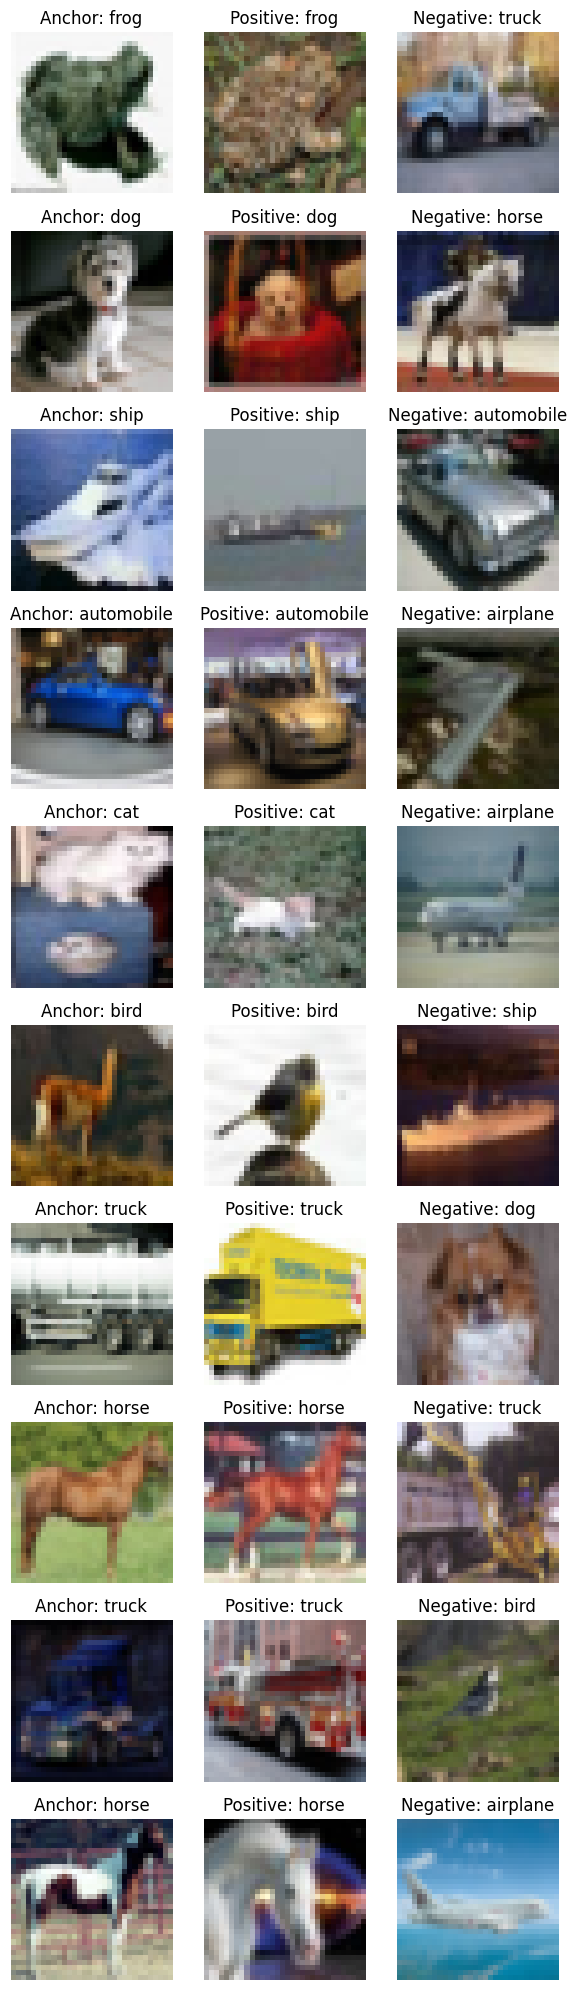

In [10]:
test_indices = np.random.choice(len(triplets), 10, replace=False)

fig, axes = plt.subplots(len(test_indices), 3, figsize=(6, 2 * len(test_indices)))

for row_idx, triplet_idx in enumerate(test_indices):
    anchor_img = triplets[triplet_idx, 0]
    positive_img = triplets[triplet_idx, 1]
    negative_img = triplets[triplet_idx, 2]
    
    anchor_label = int(triplets_labels[triplet_idx, 0])
    positive_label = int(triplets_labels[triplet_idx, 1])
    negative_label = int(triplets_labels[triplet_idx, 2])
    
    axes[row_idx, 0].imshow(anchor_img)
    axes[row_idx, 0].set_title(f'Anchor: {label_names[anchor_label]}', fontsize=12)
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_ylabel(f'Triplet {triplet_idx}', fontsize=12, rotation=0, labelpad=50)
    
    axes[row_idx, 1].imshow(positive_img)
    axes[row_idx, 1].set_title(f'Positive: {label_names[positive_label]}', fontsize=12)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(negative_img)
    axes[row_idx, 2].set_title(f'Negative: {label_names[negative_label]}', fontsize=12)
    axes[row_idx, 2].axis('off')
    
    print(f"Triplet {triplet_idx} - Anchor: {anchor_label} ({label_names[anchor_label]}), "
          f"Positive: {positive_label} ({label_names[positive_label]}), "
          f"Negative: {negative_label} ({label_names[negative_label]})")

plt.tight_layout()
plt.show()

### Defining loss

In [11]:
a = torch.Tensor([1, 1])
b = torch.Tensor([1, -1])

1 - F.cosine_similarity(a, b, dim=0)

tensor(1.)

In [12]:
def triplet_loss(anchor, positive, negative, margin=0.4):
    """Shape (B, F)"""
    positive_distances = 1 - F.cosine_similarity(anchor, positive, dim=1) # Vector of shape B
    negative_distances = 1 - F.cosine_similarity(anchor, negative, dim=1) # Vector of shape B
    loss = torch.clamp(positive_distances - negative_distances + margin, min=0)
    return loss.mean()

In [13]:
koleo_loss = KoLeoLoss()

In [14]:
def good_triplet_cosine(anchor, positive, negative):
    anchor_positive_dist = 1 - F.cosine_similarity(anchor, positive, dim=1)
    anchor_negative_dist = 1 - F.cosine_similarity(anchor, negative, dim=1)
    return anchor_positive_dist < anchor_negative_dist

def good_triplet_euclidean(anchor, positive, negative):
    anchor_positive_dist = F.pairwise_distance(anchor, positive, p=2)
    anchor_negative_dist = F.pairwise_distance(anchor, negative, p=2)
    return anchor_positive_dist < anchor_negative_dist

In [15]:
anc, pos, neg = torch.randn([10, 128]), torch.randn([10, 128]), torch.randn([10, 128])
print(good_triplet_cosine(anc, pos, neg))
print(good_triplet_euclidean(anc, pos, neg))

tensor([ True, False, False, False, False,  True,  True,  True, False, False])
tensor([ True,  True, False, False, False,  True,  True,  True, False, False])


In [16]:
a = torch.randn([64, 128]) * 2 - 1
b = torch.randn([64, 128]) * 2 - 1
c = torch.randn([64, 128]) * 2 - 1

triplet_loss(a, b, -c)

tensor(0.0555)

In [ ]:
class TripletsCIFAR10Dataset(Dataset):
    def __init__(self, triplets, transform=None, target_transform=None):
        # Triplets shape [N, T, H, W, C]
        
        self.triplets = torch.from_numpy(triplets.transpose((0,1,4,2,3)) / 255).float() # For tensor [N, T, C, H, W]

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.triplets.shape[0]

    def __getitem__(self, idx):
        triplet = self.triplets[idx]
        anchor, positive, negative = triplet[0, ...], triplet[1, ...], triplet[2, ...]
        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

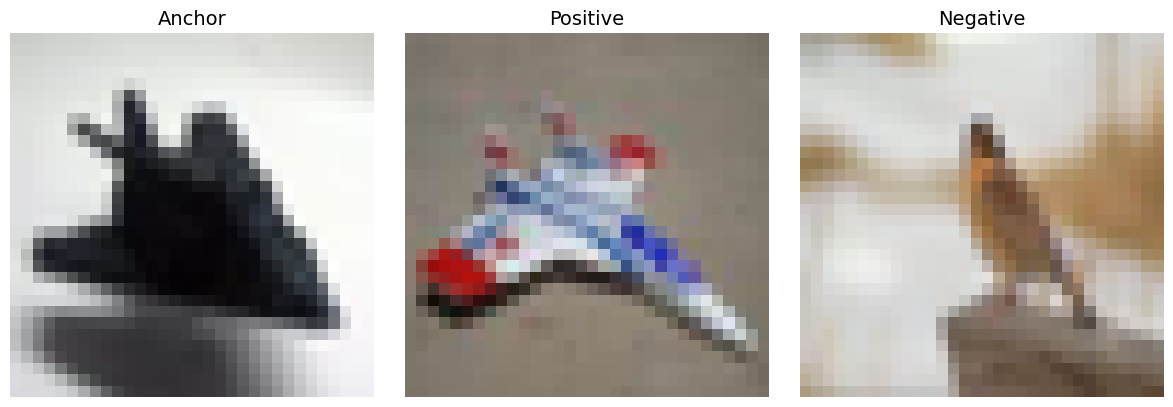

In [18]:
ds_test = TripletsCIFAR10Dataset(triplets)
a = next(iter(ds_test))

anchor, positive, negative = a

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(anchor.permute(1, 2, 0).numpy())
axes[0].set_title('Anchor', fontsize=14)
axes[0].axis('off')

axes[1].imshow(positive.permute(1, 2, 0).numpy())
axes[1].set_title('Positive', fontsize=14)
axes[1].axis('off')

axes[2].imshow(negative.permute(1, 2, 0).numpy())
axes[2].set_title('Negative', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [19]:
train_transforms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.Normalize(mean=mean, std=std)
])

In [20]:
val_transforms = T.Compose([
    T.Normalize(mean=mean, std=std)
])

In [21]:
def train_loop(net, dataloader, optimizer, miner, margin, print_freq=10, koleo_loss_coeff=None):
    net.train()
    loss_accum = 0
    epoch_loss = 0
    for batch_idx, (anc, pos, neg) in enumerate(dataloader):
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        anc_feat, pos_feat, neg_feat = net(anc), net(pos), net(neg)

        loss = triplet_loss(anc_feat, pos_feat, neg_feat, margin)
        if koleo_loss_coeff is not None:
            loss += koleo_loss_coeff * koleo_loss(torch.cat([anc_feat, pos_feat, neg_feat], dim=0))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_accum += loss.item()
        epoch_loss += loss.item()

        if (batch_idx+1) % print_freq == 0:
            print(f"Batch {batch_idx+1}: Loss = {loss_accum / print_freq}")
            loss_accum = 0

    return epoch_loss / (batch_idx + 1)

In [22]:
def validation_loop(net, dataloader, miner, margin, koleo_loss_coeff=None):
    net.eval()
    val_loss = 0
    good_triplets = 0
    total_triplets = 0

    positive_similarities = []
    negative_similarities = []
    
    positive_euclidean_distances = []
    negative_euclidean_distances = []

    with torch.no_grad():
        for batch_idx, (anc, pos, neg) in enumerate(dataloader):
            anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
            anc_feat, pos_feat, neg_feat = net(anc), net(pos), net(neg)

            loss = triplet_loss(anc_feat, pos_feat, neg_feat, margin)
            if koleo_loss_coeff is not None:
                loss += koleo_loss_coeff * koleo_loss(torch.cat([anc_feat, pos_feat, neg_feat], dim=0))

            val_loss += loss.item()

            batch_positive_euclidean_distances = F.pairwise_distance(anc_feat, pos_feat, p=2)
            batch_negative_euclidean_distances = F.pairwise_distance(anc_feat, neg_feat, p=2)
            positive_euclidean_distances.append(batch_positive_euclidean_distances)
            negative_euclidean_distances.append(batch_negative_euclidean_distances)

            batch_positive_similarities = F.cosine_similarity(anc_feat, pos_feat, dim=1)
            batch_negative_similarities = F.cosine_similarity(anc_feat, neg_feat, dim=1)
            positive_similarities.append(batch_positive_similarities)
            negative_similarities.append(batch_negative_similarities)

            good_triplets += (batch_positive_similarities > batch_negative_similarities).sum()
            total_triplets += anc.shape[0]

        positive_euclidean_distances = torch.cat(positive_euclidean_distances, dim=0)
        negative_euclidean_distances = torch.cat(negative_euclidean_distances, dim=0)

        predict_similarities = torch.cat([batch_positive_similarities, batch_negative_similarities], dim=0)
        target_similarities = torch.cat([torch.ones_like(batch_positive_similarities), torch.zeros_like(batch_negative_similarities)], dim=0)

        val_auc = roc_auc_score(target_similarities.detach().cpu().numpy(), predict_similarities.detach().cpu().numpy())
        mean_positive_similarities = predict_similarities[:len(predict_similarities)//2].mean().item()
        mean_negative_similarities = predict_similarities[len(predict_similarities)//2:].mean().item()
        mean_positive_euclidean_distances = positive_euclidean_distances.mean().item()
        mean_negative_euclidean_distances = negative_euclidean_distances.mean().item()
        good_triplets_ratio = (good_triplets / total_triplets).item()
    
    return {
        'val_loss': val_loss / (batch_idx + 1),
        'val_auc': val_auc,
        'mean_positive_similarities': mean_positive_similarities,
        'mean_negative_similarities': mean_negative_similarities,
        'mean_positive_euclidean_distances': mean_positive_euclidean_distances,
        'mean_negative_euclidean_distances': mean_negative_euclidean_distances,
        'good_triplets_ratio': good_triplets_ratio
    }


In [23]:
class VGG11Embedding(nn.Module):
    def __init__(self, pretrained):
        super(VGG11Embedding, self).__init__()
        vgg = models.vgg11(pretrained=pretrained)
        self.features = vgg.features
        self.linear = nn.Linear(512, 128)
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten to [batch_size, features]
        x = self.linear(x)
        x = F.normalize(x, p=2, dim=1)
        return x

In [24]:
net = VGG11Embedding(pretrained=True).to(device)
x = torch.randn((1, 3, 32, 32)).to(device)
print(x.view(-1)[:10])
net(x).shape

/Users/adlane/perso/koleo/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adlane/perso/koleo/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor([ 0.1249,  0.5010,  2.6589, -0.0627, -1.6449, -0.5999, -0.3833,  0.0957,
         0.6515, -0.7040], device='mps:0')


torch.Size([1, 128])

In [25]:
batch_size = 64
learning_rate = 5e-4
epochs = 1
margin = 0.5
koleo_loss_coeff = None

val_split = 0.05
num_train = int((1 - val_split) * len(triplets))
save_ckpt_freq = 1

In [26]:
shuffle_indices = np.random.permutation(len(triplets))
triplets = triplets[shuffle_indices]
triplets_labels = triplets_labels[shuffle_indices]

train_triplets = triplets[:num_train, ...]
val_triplets = triplets[num_train:]
train_labels = triplets_labels[:num_train, ...]
val_labels = triplets_labels[num_train:]

In [27]:
val_labels[:10]

array([[2., 2., 8.],
       [5., 5., 7.],
       [4., 4., 7.],
       [6., 6., 9.],
       [6., 6., 7.],
       [5., 5., 2.],
       [3., 3., 2.],
       [9., 9., 2.],
       [2., 2., 1.],
       [1., 1., 2.]])

In [28]:
train_dataset = TripletsCIFAR10Dataset(train_triplets, transform=train_transforms)
val_dataset = TripletsCIFAR10Dataset(val_triplets, transform=val_transforms)

# train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
# val_labels = [val_dataset[i][1] for i in range(len(val_dataset))]
# train_sampler = MPerClassSampler(train_labels, m=8, batch_size=batch_size, length_before_new_iter=len(train_dataset))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# miner = TripletMarginMiner(margin=margin, type_of_triplets="hard")
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [32]:
len(train_dataset)

23750

In [29]:
first_batch = next(iter(train_loader))
anchors, positives, negatives = first_batch[0], first_batch[1], first_batch[2]  # unpack triplet tensors

for i in range(3):
    print(f"Triplet {i+1}:")
    print("  Anchor mean pixel:", anchors[i].float().mean().item())
    print("  Positive mean pixel:", positives[i].float().mean().item())
    print("  Negative mean pixel:", negatives[i].float().mean().item())


Triplet 1:
  Anchor mean pixel: 0.040484365075826645
  Positive mean pixel: 0.6809932589530945
  Negative mean pixel: -0.5483747720718384
Triplet 2:
  Anchor mean pixel: -0.7496487498283386
  Positive mean pixel: -1.2591006755828857
  Negative mean pixel: -0.3983496427536011
Triplet 3:
  Anchor mean pixel: -0.3044559061527252
  Positive mean pixel: -0.19607847929000854
  Negative mean pixel: 0.06921915709972382


In [30]:
runs_dir = Path('runs')
runs_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_dir = runs_dir / timestamp
save_dir.mkdir(exist_ok=True)

with (save_dir / "config.json").open("w") as fp:
    json.dump({
        "seed": seed,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "margin": margin,
        "koleo_loss_coeff": koleo_loss_coeff,
        "val_split": val_split,
        "num_train": num_train,
        "save_ckpt_freq": save_ckpt_freq
    }, fp, indent=4)

In [31]:
metrics_path = save_dir / "training_metrics.csv"

train_losses = []
val_losses = []
best_auc = 0

csv_headers = [
    "epoch",
    "train_loss",
    "val_loss",
    "val_auc",
    "mean_positive_similarities",
    "mean_negative_similarities",
    "mean_positive_euclidean_distances",
    "mean_negative_euclidean_distances",
    "good_triplets_ratio"
]

with open(metrics_path, mode='w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=csv_headers)
    writer.writeheader()

val_metrics = validation_loop(net, val_loader, None, margin)
print(f"Before training, epoch 0 - Validation loss = {val_metrics['val_loss']}")
print(
    f"Validation metrics - "
    f"val_loss: {val_metrics['val_loss']:.4f}, "
    f"val_auc: {val_metrics['val_auc']:.4f}, "
    f"mean_positive_similarities: {val_metrics['mean_positive_similarities']:.4f}, "
    f"mean_negative_similarities: {val_metrics['mean_negative_similarities']:.4f}, "
    f"mean_positive_euclidean_distances: {val_metrics['mean_positive_euclidean_distances']:.4f}, "
    f"mean_negative_euclidean_distances: {val_metrics['mean_negative_euclidean_distances']:.4f}, "
    f"good_triplets_ratio: {val_metrics['good_triplets_ratio']:.4f}"
)
with open(metrics_path, mode='a', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=csv_headers)
    writer.writerow({
        "epoch": 0,
        "train_loss": "",  # No train_loss before training
        "val_loss": val_metrics['val_loss'],
        "val_auc": val_metrics['val_auc'],
        "mean_positive_similarities": val_metrics['mean_positive_similarities'],
        "mean_negative_similarities": val_metrics['mean_negative_similarities'],
        "mean_positive_euclidean_distances": val_metrics['mean_positive_euclidean_distances'],
        "mean_negative_euclidean_distances": val_metrics['mean_negative_euclidean_distances'],
        "good_triplets_ratio": val_metrics['good_triplets_ratio']
    })

for epoch_idx in range(epochs):
    train_loss = train_loop(net, train_loader, optimizer, None, margin, print_freq=100, koleo_loss_coeff=koleo_loss_coeff)
    val_metrics = validation_loop(net, val_loader, None, margin, koleo_loss_coeff=koleo_loss_coeff)
    val_losses.append(val_metrics['val_loss'])
    train_losses.append(train_loss if epoch_idx > 0 else val_metrics['val_loss'])
    print(f"Epoch {epoch_idx+1} - Train loss = {train_loss}, Validation loss = {val_metrics['val_loss']}")
    print(
        f"Validation metrics - "
        f"val_loss: {val_metrics['val_loss']:.4f}, "
        f"val_auc: {val_metrics['val_auc']:.4f}, "
        f"mean_positive_similarities: {val_metrics['mean_positive_similarities']:.4f}, "
        f"mean_negative_similarities: {val_metrics['mean_negative_similarities']:.4f}, "
        f"mean_positive_euclidean_distances: {val_metrics['mean_positive_euclidean_distances']:.4f}, "
        f"mean_negative_euclidean_distances: {val_metrics['mean_negative_euclidean_distances']:.4f}, "
        f"good_triplets_ratio: {val_metrics['good_triplets_ratio']:.4f}"
    )

    with open(metrics_path, mode='a', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=csv_headers)
        writer.writerow({
            "epoch": epoch_idx + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics['val_loss'],
            "val_auc": val_metrics['val_auc'],
            "mean_positive_similarities": val_metrics['mean_positive_similarities'],
            "mean_negative_similarities": val_metrics['mean_negative_similarities'],
            "mean_positive_euclidean_distances": val_metrics['mean_positive_euclidean_distances'],
            "mean_negative_euclidean_distances": val_metrics['mean_negative_euclidean_distances'],
            "good_triplets_ratio": val_metrics['good_triplets_ratio']
        })

    if val_metrics['val_auc'] > best_auc:
        best_auc = val_metrics['val_auc']
        torch.save(net.state_dict(), save_dir / f'best_epoch_{epoch_idx+1}.pth')
        print(f"New best AUC: {best_auc:.4f} at epoch {epoch_idx+1}")
        
    if (epoch_idx+1) % save_ckpt_freq == 0:
        torch.save(net.state_dict(), save_dir / f'epoch_{epoch_idx+1}.pth')

Before training, epoch 0 - Validation loss = 0.4225699856877327
Validation metrics - val_loss: 0.4226, val_auc: 0.6497, mean_positive_similarities: 0.2695, mean_negative_similarities: 0.1868, mean_positive_euclidean_distances: 1.1882, mean_negative_euclidean_distances: 1.2545, good_triplets_ratio: 0.6528
Batch 100: Loss = 0.3177324356138706
Batch 200: Loss = 0.260526310056448
Batch 300: Loss = 0.24057323724031449
Epoch 1 - Train loss = 0.2635776057679166, Validation loss = 0.230690386146307
Validation metrics - val_loss: 0.2307, val_auc: 0.8131, mean_positive_similarities: 0.7250, mean_negative_similarities: 0.1455, mean_positive_euclidean_distances: 0.6456, mean_negative_euclidean_distances: 1.2223, good_triplets_ratio: 0.8032
New best AUC: 0.8131 at epoch 1


#### Load state dict if needed

In [32]:
save_dir = Path("runs/20251129_103031")
net.load_state_dict(torch.load(save_dir / 'epoch_3.pth'))

<All keys matched successfully>

### Plot losses

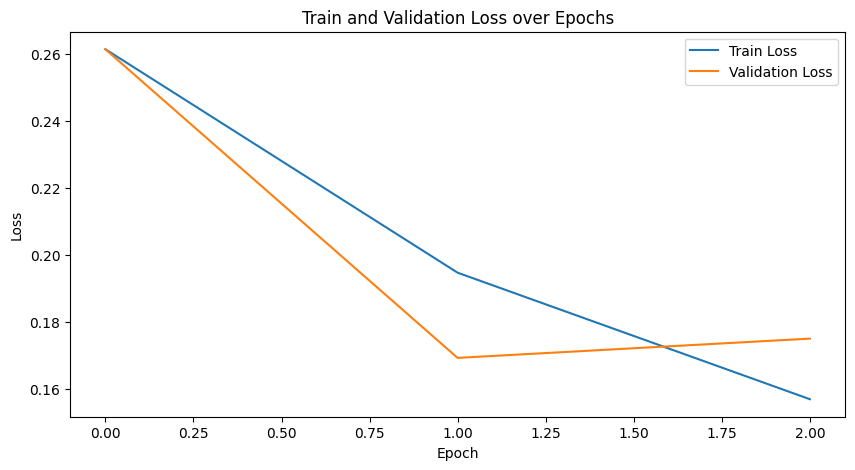

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss over Epochs')
plt.legend()
plt.show()


### Construct embeddings by class of validation dataset

In [85]:
net.eval()

val_transform = T.Compose([
    T.Normalize(mean=mean, std=std)
])

embeddings_by_class = {i: [] for i in range(10)} # dict of labels as keys, and a list of embeddings as value

with torch.no_grad():
    anchor_labels = val_labels[:, 0]
    
    for idx in range(len(val_triplets)):
        label = int(anchor_labels[idx])
        
        img = torch.from_numpy(val_triplets[idx, 0].transpose(2, 0, 1) / 255.0).float()
        img = val_transform(img)
        img = img.unsqueeze(0).to(device)
        
        embedding = net(img)
        embeddings_by_class[label].append(embedding.cpu())

embeddings_by_class = {label: torch.cat(embeddings_by_class[label], dim=0) for label in range(10)}
samples_per_class = [len(embeddings_by_class[i]) for i in range(10)]

print(f"Samples per class: {samples_per_class}")

Samples per class: [123, 128, 143, 127, 123, 127, 131, 132, 80, 136]


### Compute distance matrix 

In [86]:
dist_matrix = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        emb_i = embeddings_by_class[i]
        emb_j = embeddings_by_class[j]
        
        emb_i_norm = F.normalize(emb_i, p=2, dim=1)
        emb_j_norm = F.normalize(emb_j, p=2, dim=1)
        
        cosine_sim = torch.mm(emb_i_norm, emb_j_norm.t())
        cosine_dist = 1 - cosine_sim
        
        dist_matrix[i, j] = cosine_dist.mean().item()

print(f"Distance matrix shape: {dist_matrix.shape} (10x10)")
dist_matrix

Distance matrix shape: (10, 10) (10x10)


array([[0.29319847, 0.95399159, 0.51621646, 0.88093489, 0.68233657,
        1.00186634, 0.97898662, 1.00079787, 0.48430634, 0.94263452],
       [0.95399153, 0.16109529, 1.32003033, 1.38177049, 1.34653282,
        1.42730689, 1.25013101, 1.31808913, 0.69330239, 0.16351801],
       [0.51621652, 1.32003033, 0.14917694, 0.47253108, 0.24052036,
        0.57952887, 0.52356476, 0.81239349, 0.98550659, 1.30346346],
       [0.88093489, 1.38177061, 0.47253108, 0.40487212, 0.56671649,
        0.42300498, 0.58347672, 0.81549489, 1.1956079 , 1.37804472],
       [0.68233657, 1.34653282, 0.24052036, 0.56671643, 0.17282882,
        0.63963693, 0.5792768 , 0.61760294, 1.18407547, 1.29967785],
       [1.00186646, 1.42730665, 0.57952887, 0.42300498, 0.63963687,
        0.39965668, 0.68493187, 0.75764984, 1.29490304, 1.40861845],
       [0.97898656, 1.25013101, 0.5235647 , 0.58347672, 0.57927668,
        0.68493193, 0.16642375, 1.0896244 , 1.15764904, 1.33987164],
       [1.00079799, 1.31808925, 0.8123934

#### Plot the distance matrix heatmap

Distance matrix heatmap saved at runs/20251129_110354/distance_matrix_heatmap.png


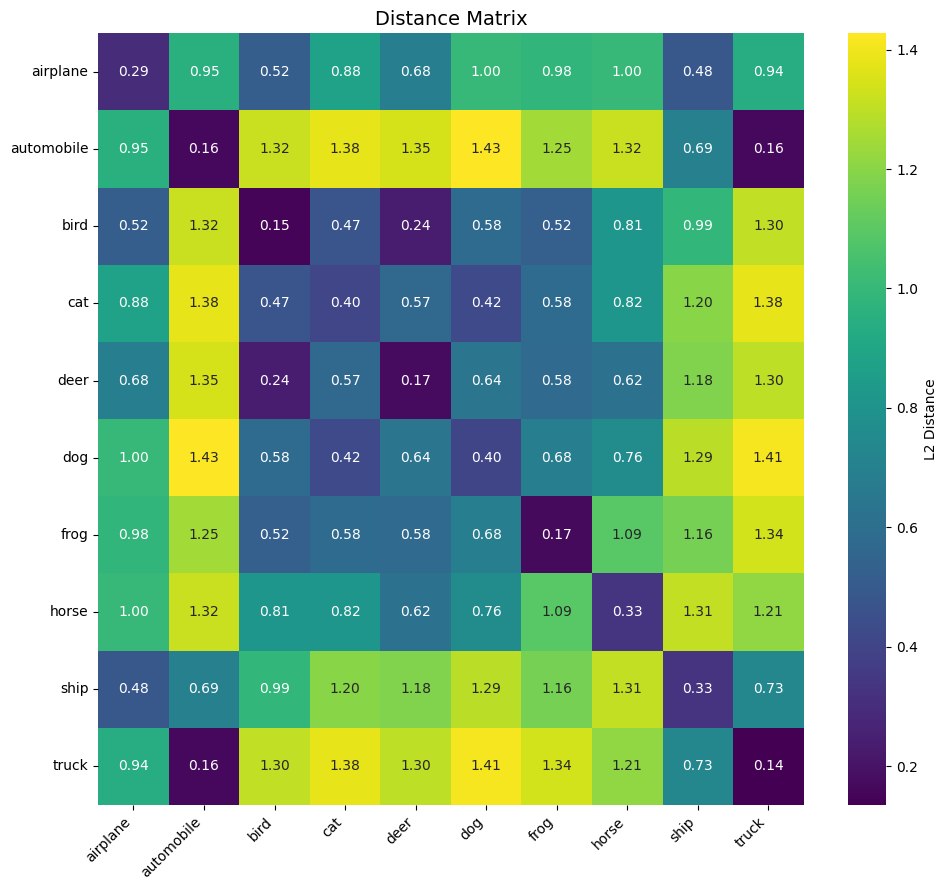


Diagonal (same-class distances):
  airplane: 0.2932
  automobile: 0.1611
  bird: 0.1492
  cat: 0.4049
  deer: 0.1728
  dog: 0.3997
  frog: 0.1664
  horse: 0.3329
  ship: 0.3307
  truck: 0.1352

Same-class distances: mean=0.2546, std=0.1028
Different-class distances: mean=0.9230, std=0.3499
Separation margin: 0.6684


In [87]:
plt.figure(figsize=(10, 9))

col_labels = [f"{label_names[i]}" for i in range(10)]
row_labels = [f"{label_names[i]}" for i in range(10)]

sns.heatmap(dist_matrix, 
            xticklabels=col_labels, 
            yticklabels=row_labels,
            annot=True,
            fmt='.2f',
            cmap='viridis', 
            cbar_kws={'label': 'L2 Distance'})

plt.title('Distance Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plot_filename = save_dir / "distance_matrix_heatmap.png"
plt.savefig(plot_filename)
print(f"Distance matrix heatmap saved at {plot_filename}")

plt.show()
plt.close()

same_class_dists = np.diag(dist_matrix)
diff_class_dists = []
for i in range(10):
    for j in range(10):
        if i != j:
            diff_class_dists.append(dist_matrix[i, j])

print(f"\nDiagonal (same-class distances):")
for i in range(10):
    print(f"  {label_names[i]}: {dist_matrix[i, i]:.4f}")

print(f"\nSame-class distances: mean={np.mean(same_class_dists):.4f}, std={np.std(same_class_dists):.4f}")
print(f"Different-class distances: mean={np.mean(diff_class_dists):.4f}, std={np.std(diff_class_dists):.4f}")
print(f"Separation margin: {np.mean(diff_class_dists) - np.mean(same_class_dists):.4f}")


### Compute the mean of distances between anchor and positive images and between anchor and negative images

In [88]:
val_transform = T.Compose([
    T.Normalize(mean=mean, std=std)
])

positive_distances = []
negative_distances = []
with torch.no_grad():
    for batch_idx, (anc, pos, neg) in enumerate(val_loader):
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        anc_feat, pos_feat, neg_feat = net(anc), net(pos), net(neg)

        batch_positive_distances = F.cosine_similarity(anc_feat, pos_feat, dim=1)
        batch_negative_distances = F.cosine_similarity(anc_feat, neg_feat, dim=1)
        positive_distances.append(batch_positive_distances)
        negative_distances.append(batch_negative_distances)
        
positive_distances = torch.cat(positive_distances, dim=0)
negative_distances = torch.cat(negative_distances, dim=0)

print(positive_distances.mean())
print(negative_distances.mean())

tensor(0.7413, device='mps:0')
tensor(0.0932, device='mps:0')


### Compute the ROC curve and the AUC value

In [89]:
predict_distances = torch.cat([positive_distances, negative_distances], dim=0).detach().cpu().numpy()
target_distances = torch.cat([torch.ones_like(positive_distances), torch.zeros_like(negative_distances)], dim=0).detach().cpu().numpy()

fpr, tpr, thresholds = roc_curve(target_distances, predict_distances)
auc = roc_auc_score(target_distances, predict_distances)

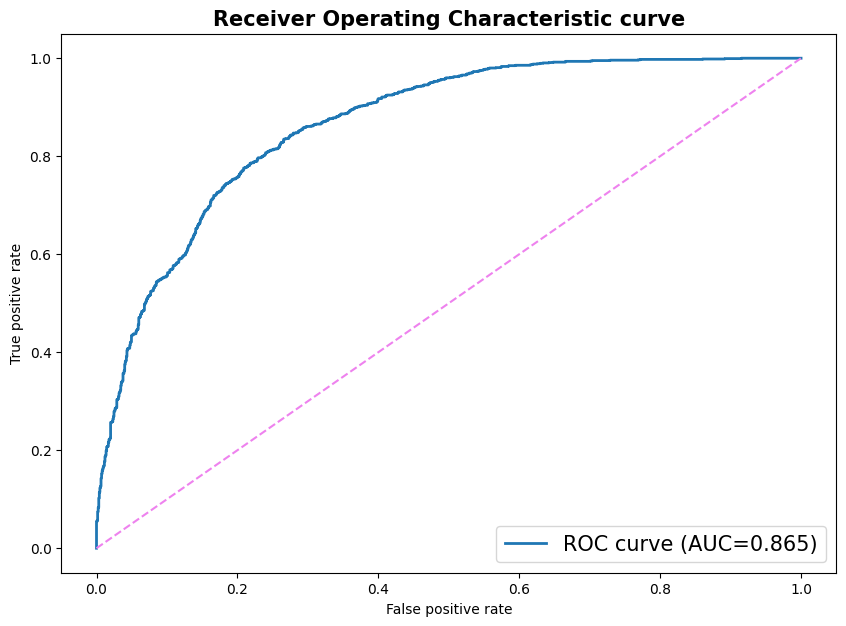

In [90]:
fig = plt.figure(figsize=[10,7])

plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], c='violet', ls='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.legend(loc="lower right", fontsize=15)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver Operating Characteristic curve', weight='bold', fontsize=15)

# Save the figure
save_path = Path(save_dir) / "roc_curve.png"
plt.savefig(save_path)

plt.show()

### 3D PCA

In [91]:
all_embeddings = torch.cat([embeddings_by_class[k] for k in embeddings_by_class], dim=0)
all_embeddings.shape

torch.Size([1250, 128])

In [92]:
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(all_embeddings)

#### Displaying the 3D scatter

In [93]:
labels_array = np.concatenate([np.full(count, label) for label, count in enumerate(samples_per_class)])

pca_3d_df = pd.DataFrame({
    'PC1': embeddings_3d[:, 0],
    'PC2': embeddings_3d[:, 1],
    'PC3': embeddings_3d[:, 2],
    'Label': labels_array,
    'Class': [label_names[int(label)] for label in labels_array]
})

fig = px.scatter_3d(pca_3d_df, x='PC1', y='PC2', z='PC3', 
                    color='Class',
                    color_discrete_sequence=px.colors.qualitative.T10,
                    hover_data={'Label': True, 'Class': True, 'PC1': ':.3f', 'PC2': ':.3f', 'PC3': ':.3f'},
                    title='PCA 3D Projection of Embeddings by Class',
                    opacity=0.7)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=1000,
    height=800,
    legend=dict(title='Classes')
)

fig.show()

### 2D PCA

In [94]:
pca_2d = PCA(n_components=2)
embeddings_2d = pca_2d.fit_transform(all_embeddings)

Normalize embeddings

In [95]:
embeddings_2d = (embeddings_2d - embeddings_2d.min(axis=0)) / (embeddings_2d.max(axis=0) - embeddings_2d.min(axis=0))

#### Displaying the 2D scatter with confidence ellipse

In [96]:
def compute_ellipse_parameters(embeddings, coverage):
    center = np.median(embeddings, axis=0)
    print(center)
    cov = np.cov(embeddings, rowvar=False)
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        inv_cov = np.linalg.pinv(cov)

    # Squared Mahalanobis distances and empirical quantile for coverage
    d2 = np.einsum("ij,jk,ik->i", embeddings - center, inv_cov, embeddings - center)
    threshold = np.quantile(d2, coverage)

    # Ellipse parameters from covariance eigendecomposition
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2.0 * np.sqrt(vals * threshold)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    return center, width, height, angle

Compute the ellipse parameters of each class

In [97]:
coverage = 0.50

ellipse_params = {}
for cls in label_names:
    cls_idx = label_names.index(cls)
    X = embeddings_2d[labels_array == cls_idx]

    center, width, height, angle = compute_ellipse_parameters(X, coverage)
    ellipse_params[cls] = {"center": center.tolist(), "width": float(width), "height": float(height), "angle": float(angle)}


[0.56514292 0.10621939]
[0.03600995 0.45514289]
[0.91629183 0.22828709]
[0.90877972 0.4945098 ]
[0.89893576 0.36270556]
[0.88471467 0.63443011]
[0.84256476 0.32876873]
[0.72186888 0.8324786 ]
[0.25171664 0.1474433 ]
[0.03814265 0.4896725 ]


In [98]:
def hex_to_rgba(hex_color, alpha):
    h = hex_color.lstrip('#')
    r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'

In [99]:
pca_2d_df = pd.DataFrame({
    'PC1': embeddings_2d[:, 0],
    'PC2': embeddings_2d[:, 1],
    'Label': labels_array,
    'Class': [label_names[int(label)] for label in labels_array]
})

fig = px.scatter(
    pca_2d_df, x='PC1', y='PC2',
    color='Class',
    color_discrete_sequence=px.colors.qualitative.T10,
    hover_data={'Label': True, 'Class': True, 'PC1': ':.3f', 'PC2': ':.3f'},
    title='PCA 2D Projection of Embeddings by Class',
    opacity=0.7
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    xaxis_title='PC1',
    yaxis_title='PC2',
    width=1000,
    height=800,
    legend=dict(title='Classes')
)

# For legend and fill colors:
class_to_color = {
    tr.legendgroup: tr.marker.color
    for tr in fig.data
    if getattr(tr, "mode", "") == "markers" and tr.legendgroup
}

# Plot for display (ellipses as legendonly, ellipses have legend entry)
for cls, g in pca_2d_df.groupby('Class'):
    ep = ellipse_params[cls]
    center, w, h, angle = ep["center"], ep["width"], ep["height"], ep["angle"]

    t = np.linspace(0, 2 * np.pi, 200)
    ex, ey = (w / 2) * np.cos(t), (h / 2) * np.sin(t)
    c, s = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
    x = c * ex - s *ey + center[0]
    y = s * ex + c * ey + center[1]

    col = class_to_color.get(cls, px.colors.qualitative.T10[0])
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines',
        name=f'{cls} ellipse',
        legendgroup=str(cls),
        showlegend=True,
        visible='legendonly',
        line=dict(color=col, width=2),
        fill='toself',
        fillcolor=hex_to_rgba(col, 0.12),
        hoverinfo='skip'
    ))

fig.update_layout(legend=dict(
    title='Classes',
    groupclick='toggleitem',
    itemclick='toggle',
    itemdoubleclick='toggleothers',
    tracegroupgap=6
))
fig.show()

# Save version with all ellipses visible, but no ellipse legend
fig_all_ellipses = px.scatter(
    pca_2d_df, x='PC1', y='PC2',
    color='Class',
    color_discrete_sequence=px.colors.qualitative.T10,
    hover_data={'Label': True, 'Class': True, 'PC1': ':.3f', 'PC2': ':.3f'},
    title='PCA 2D Projection of Embeddings by Class',
    opacity=0.7
)
fig_all_ellipses.update_traces(marker=dict(size=6))
fig_all_ellipses.update_layout(
    xaxis_title='PC1',
    yaxis_title='PC2',
    width=1000,
    height=800,
    legend=dict(title='Classes')
)
class_to_color = {
    tr.legendgroup: tr.marker.color
    for tr in fig_all_ellipses.data
    if getattr(tr, "mode", "") == "markers" and tr.legendgroup
}

for cls, g in pca_2d_df.groupby('Class'):
    ep = ellipse_params[cls]
    center, w, h, angle = ep["center"], ep["width"], ep["height"], ep["angle"]

    t = np.linspace(0, 2 * np.pi, 200)
    ex, ey = (w / 2) * np.cos(t), (h / 2) * np.sin(t)
    c, s = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
    x = c * ex - s * ey + center[0]
    y = s * ex + c * ey + center[1]

    col = class_to_color.get(cls, px.colors.qualitative.T10[0])
    # These ellipses are NOT shown in the legend
    fig_all_ellipses.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines',
        name=None,
        legendgroup=str(cls),
        showlegend=False,
        line=dict(color=col, width=2),
        fill='toself',
        fillcolor=hex_to_rgba(col, 0.12),
        hoverinfo='skip'
    ))

# Save PNG (save_dir must exist)
png_path = save_dir / "embeddings_2d_with_ellipses.png"
fig_all_ellipses.write_image(str(png_path), scale=2, width=1000, height=800)

In [100]:
mean_area = 0
for ep_dict in ellipse_params.values():
    area = np.pi * ep_dict["width"] * ep_dict["height"]
    ep_dict["area"] = area
    mean_area += area

mean_area /= len(ellipse_params)
mean_area

0.13219668858091002

In [102]:
areas = [ep_dict["area"] for ep_dict in ellipse_params.values()]
median_area = np.median(areas)
median_area


np.float64(0.08813082465093407)

In [103]:
ellipse_params

{'airplane': {'center': [0.5651429240404485, 0.10621939400464038],
  'width': 0.40272776083071143,
  'height': 0.17601612458738278,
  'angle': 175.22871394272923,
  'area': 0.22269675810272074},
 'automobile': {'center': [0.03600995128044559, 0.4551428914737612],
  'width': 0.14095405188860066,
  'height': 0.054687458710807275,
  'angle': 141.0139207590338,
  'area': 0.024216712164346753},
 'bird': {'center': [0.9162918258232412, 0.2282870894159784],
  'width': 0.10615581731135176,
  'height': 0.08716067428564928,
  'angle': 131.5201223891604,
  'area': 0.029067939821571246},
 'cat': {'center': [0.9087797247802109, 0.4945097978100223],
  'width': 0.43211958324347854,
  'height': 0.22127118560494333,
  'angle': 99.93787110629594,
  'area': 0.30038530582173145},
 'deer': {'center': [0.898935757343635, 0.3627055627278181],
  'width': 0.21983039155029094,
  'height': 0.06955897977832902,
  'angle': 100.7919878323642,
  'area': 0.048038651717150195},
 'dog': {'center': [0.8847146731715784, 

In [104]:
ellipse_results = {
    "ellipse_params": ellipse_params,
    "mean_area": mean_area,
    "median_area": median_area
}
with (save_dir / "ellipse.json").open("w") as fp:
    json.dump(ellipse_results, fp, indent=4)